## Customer Churn Analysis for the Telco 

In [50]:
# imports and loads

import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

os.makedirs('./results', exist_ok=True)


unclean_df = pd.read_csv('./data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = unclean_df.dropna().drop_duplicates()

# UTILITIES
df['has_churned'] =  df['Churn'] == 'Yes'
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
# df.to_excel('./excel.xlsx')


# Add the column that classifies the customers by tenure cohort
bins = [0, 3, 6, 9, 12, 24, 50, float('inf')]
labels = ['0-3', '4-6', '7-9', '10-12', '13-24', '25-50', '50+']

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)


### General Metrics

In [51]:
# overall mertics
total_customers = df['customerID'].count()
churn_true = (df['Churn'] == 'Yes').sum()
total_churn_rate = round((churn_true / total_customers) * 100, 2)
total_retention_rate = (100 - total_churn_rate).round(2)

print(f"Total Customers: {total_customers}")
print(f"Churned: {churn_true}")
print(f"Churn Rate: {total_churn_rate}%")
print(f"Retention Rate: {total_retention_rate}%")

Total Customers: 7043
Churned: 1869
Churn Rate: 26.54%
Retention Rate: 73.46%


### Churn by Segments 
#### Churn by Partnership

In [57]:
# Your existing segment analysis (paste your code here)
# Partners
partners = df[df['Partner'] == 'Yes']
non_partners = df[df['Partner'] == 'No']

churn_rate_partners = round((partners['Churn'] == 'Yes').mean() * 100, 2)
churn_rate_non_partners = round((non_partners['Churn'] == 'Yes').mean() * 100, 2)

print("Churn Rates by Segment:")
print(f"Partners: {churn_rate_partners}%")
print(f"Non-Partners: {churn_rate_non_partners}%")

Churn Rates by Segment:
Partners: 19.66%
Non-Partners: 32.96%


#### Churn by Contract 

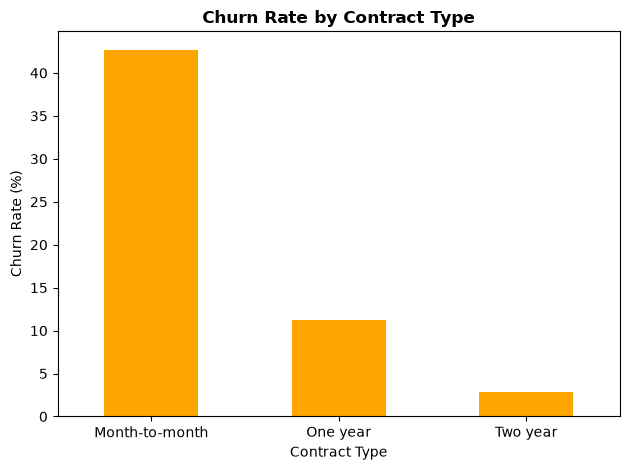

In [58]:
plt.figure()
churn_by_contract = (df.groupby('Contract')['has_churned'].mean() * 100).round(2)
churn_by_contract.plot(kind='bar', color='orange')
plt.title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('./results/01_churn_by_contract.png', dpi=300)
plt.show()

#### Churn By Tenure
##### Churn By Tenure Cohort

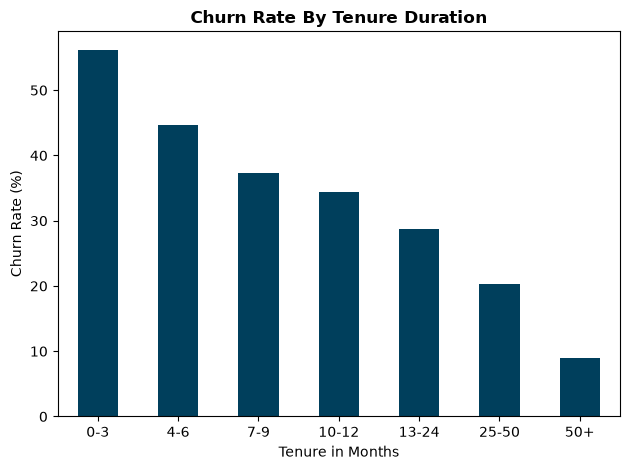

In [59]:
# churn by tenure 
plt.figure()

churn_by_tenure_group = (df.groupby('tenure_group')['has_churned'].mean() * 100).round(2)
churn_by_tenure_group.plot(kind='bar', color="#003f5c")
plt.title("Churn Rate By Tenure Duration", fontsize=12, fontweight="bold")
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure in Months')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('./results/02_churn_by_tenure.png', dpi=300)
plt.show()


##### Comparison of Churn and Retain Rate According to Tenure Duration 

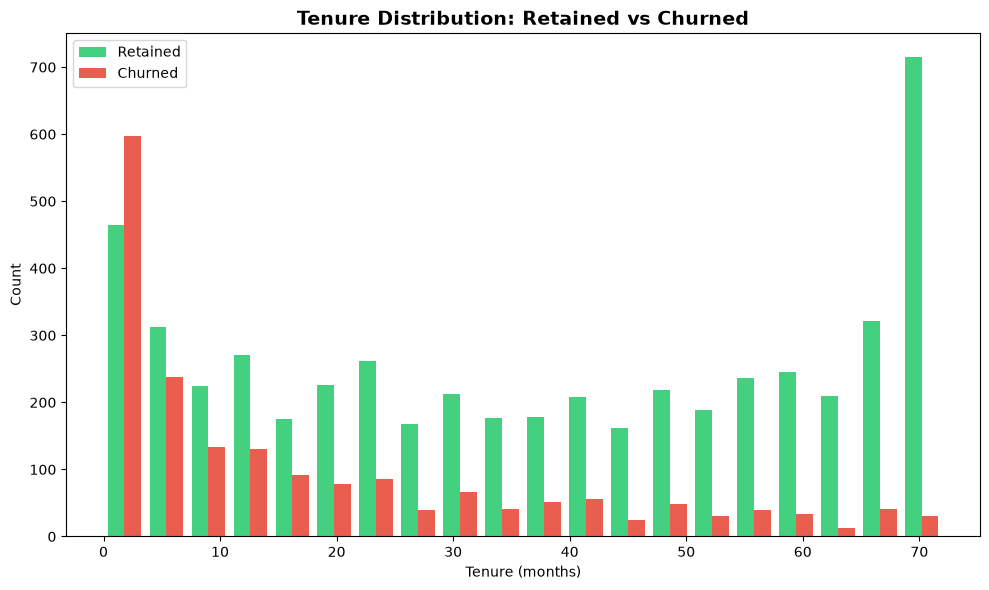

In [60]:
plt.figure(figsize=(10, 6))
churned = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']
plt.hist([retained, churned], bins=20, label=['Retained', 'Churned'], color=['#2ecc71', '#e74c3c'], alpha=0.9)
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.title('Tenure Distribution: Retained vs Churned', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('./results/03_tenure_distribution.png', dpi=300)
plt.show()

#### Montly Charges Analysis: Churned vs Retailed

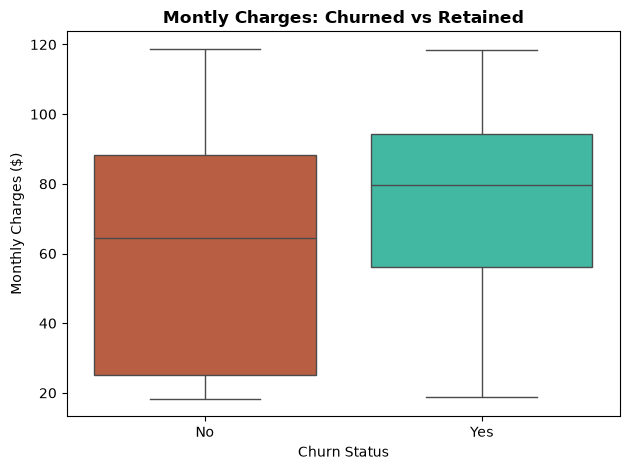

In [ ]:
# Montly Charges: Churned vs Retailed

plt.figure()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',hue='Churn', palette=["#cc532ede", "#2eccaf"], legend=False)
plt.title('Montly Charges: Churned vs Retained', fontsize=12, fontweight='bold')
plt.ylabel('Monthly Charges ($)')
plt.xlabel('Churn Status')
plt.tight_layout()
plt.savefig('./results/04_charges_comparison.png', dpi=300)


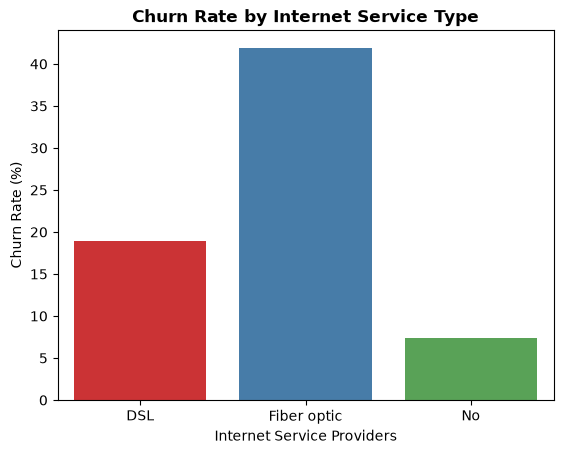

In [ ]:
plt.figure()
churn_by_internet = (df.groupby('InternetService')['has_churned'].mean() * 100).round(2)
churn_by_internet_df = churn_by_internet.reset_index()
churn_by_internet_df.columns = ['InternetService', 'ChurnRate']

sns.barplot(data=churn_by_internet_df, x='InternetService', y='ChurnRate', palette="Set1", hue="InternetService")
plt.title("Churn Rate by Internet Service Type", fontsize=12, fontweight='bold')
plt.xlabel('Internet Service Providers')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('./results/05_churn_by_internet_service.png', dpi=300)
plt.show()


#

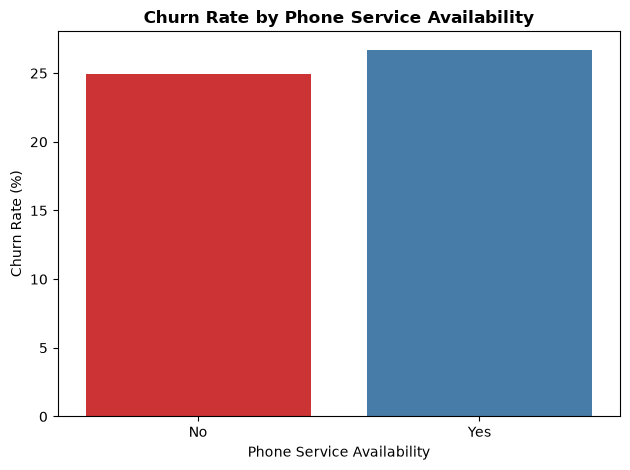

In [108]:
# Churn by phone service

plt.Figure()
churn_rate_by_phone_service = (df.groupby('PhoneService')['has_churned'].mean() * 100).round(2)
churn_rate_by_phone_service_df = churn_rate_by_phone_service.reset_index()
sns.barplot(data=churn_rate_by_phone_service_df, x='PhoneService', y='has_churned', palette='Set1', hue='PhoneService')
plt.title('Churn Rate by Phone Service Availability', fontsize=12, fontweight='bold')
plt.xlabel('Phone Service Availability')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('./results/06_churn_by_phone_service_availability.png')
plt.show()




